# GLCM Texture Metrics

Gray-Level Co-occurrence Matrix (GLCM) texture features capture spatial patterns in raster data that spectral bands alone cannot distinguish. They were introduced by Haralick et al. (1973) and remain a standard tool in remote sensing classification, geological mapping, and medical imaging.

`xrspatial.glcm_texture` computes six Haralick features over a sliding window:

| Metric | What it measures |
|---|---|
| **contrast** | Intensity difference between neighboring pixels |
| **dissimilarity** | Mean absolute gray-level difference |
| **homogeneity** | Inverse difference moment (smooth vs. rough) |
| **energy** | Sum of squared GLCM entries (uniformity) |
| **correlation** | Linear dependency of gray levels |
| **entropy** | Randomness of the co-occurrence distribution |

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from xrspatial import glcm_texture

## Synthetic test raster

We'll build a 100x100 raster with four quadrants that have distinct textures: smooth, noisy, striped, and checkerboard. GLCM metrics should clearly separate these regions.

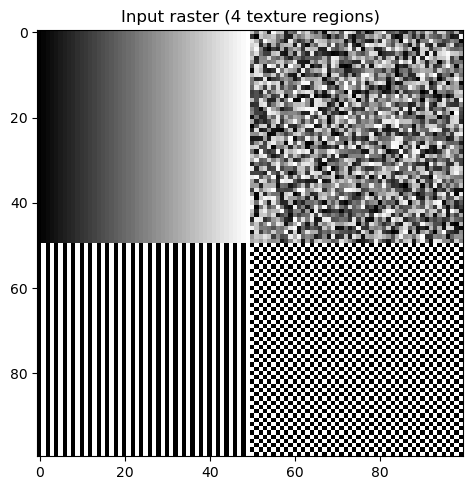

In [ ]:
# Build a 100x100 raster with four texture quadrants
rng = np.random.default_rng(42)
data = np.zeros((100, 100), dtype=np.float64)

# Top-left: smooth gradient
data[:50, :50] = np.linspace(0, 1, 50)[np.newaxis, :]

# Top-right: random noise
data[:50, 50:] = rng.random((50, 50))

# Bottom-left: vertical stripes
data[50:, :50] = np.tile([0.0, 1.0], 25)[np.newaxis, :]

# Bottom-right: checkerboard
cb = np.zeros((50, 50))
cb[::2, 1::2] = 1.0
cb[1::2, ::2] = 1.0
data[50:, 50:] = cb

agg = xr.DataArray(data, dims=['y', 'x'])

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(data, cmap='gray')
ax.set_title('Input raster (4 texture regions)')
plt.tight_layout()
plt.show()

## Computing a single metric

The simplest usage: pass a single metric name and get a 2-D result back.

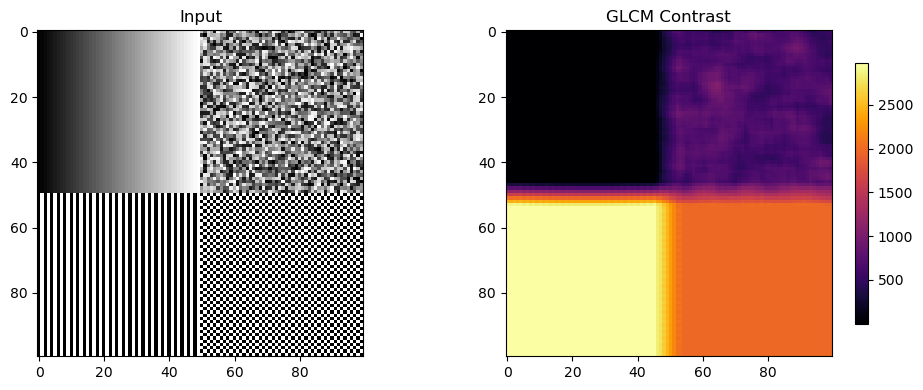

In [ ]:
contrast = glcm_texture(agg, metric='contrast', window_size=7, levels=64)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(data, cmap='gray')
axes[0].set_title('Input')
im = axes[1].imshow(contrast.values, cmap='inferno')
axes[1].set_title('GLCM Contrast')
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()

## Computing multiple metrics at once

Pass a list of metric names to get a 3-D result with a leading `metric` dimension. This is more efficient than calling `glcm_texture` separately for each metric when using the numpy backend, since the GLCM is built once per window position.

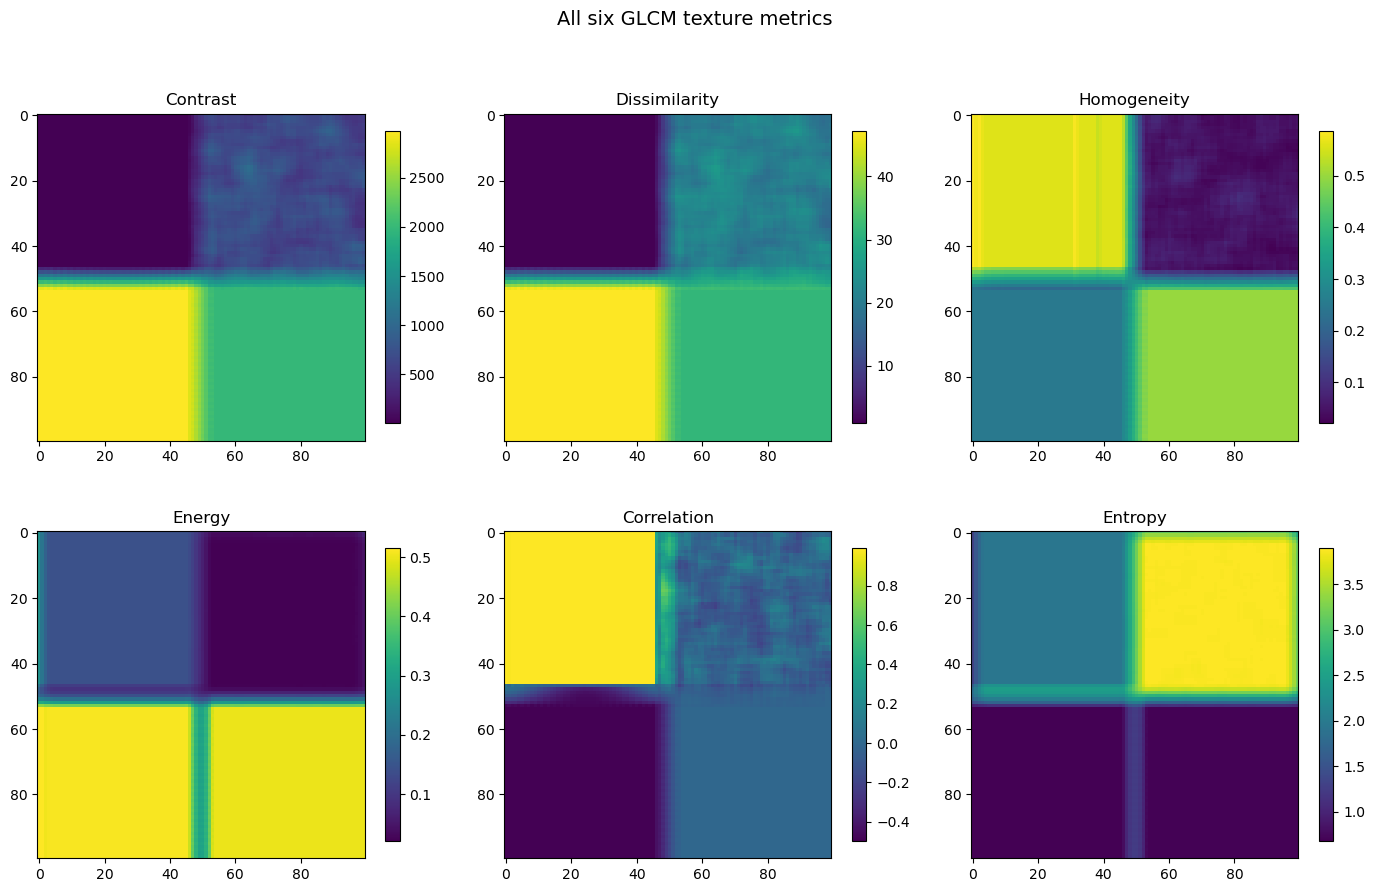

In [ ]:
metrics = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'entropy']
textures = glcm_texture(agg, metric=metrics, window_size=7, levels=64)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, name in zip(axes.flat, metrics):
    vals = textures.sel(metric=name).values
    im = ax.imshow(vals, cmap='viridis')
    ax.set_title(name.capitalize())
    plt.colorbar(im, ax=ax, shrink=0.7)
plt.suptitle('All six GLCM texture metrics', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Effect of angle

The `angle` parameter controls the direction of pixel pairing:
- `0` -- horizontal (right)
- `45` -- upper-right diagonal
- `90` -- vertical (up)
- `135` -- upper-left diagonal
- `None` (default) -- average over all four

Directional textures like stripes respond differently depending on the angle.

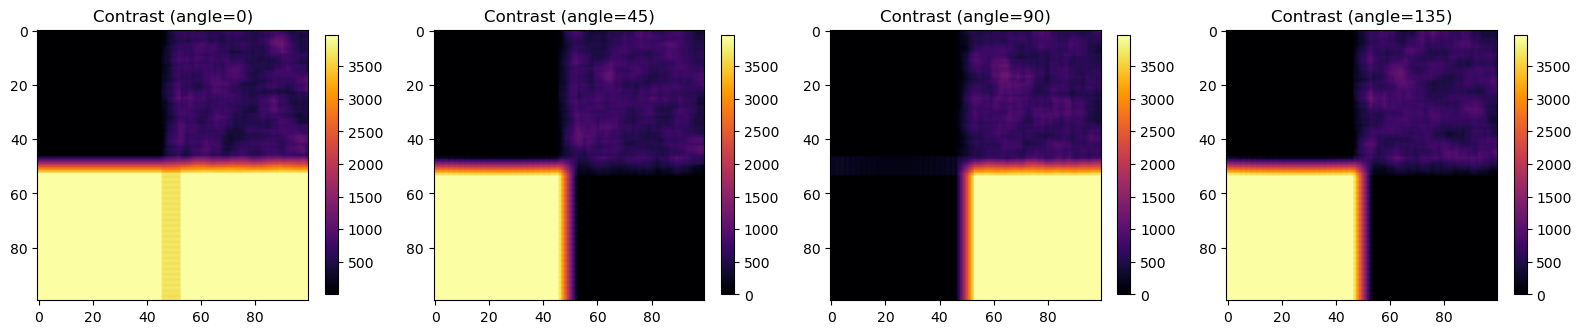

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, ang in zip(axes, [0, 45, 90, 135]):
    result = glcm_texture(agg, metric='contrast', window_size=7,
                          levels=64, angle=ang)
    im = ax.imshow(result.values, cmap='inferno')
    ax.set_title(f'Contrast (angle={ang})')
    plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

## Dask support

`glcm_texture` works on chunked Dask arrays out of the box. The input is quantized globally (so gray-level mapping stays consistent across chunks), then each chunk computes GLCM features independently via `map_overlap`.

In [ ]:
import dask.array as da

dask_agg = xr.DataArray(
    da.from_array(data, chunks=(50, 50)),
    dims=['y', 'x'],
)

dask_contrast = glcm_texture(dask_agg, metric='contrast',
                             window_size=7, levels=64)
print(f'Result type: {type(dask_contrast.data)}')
print(f'Chunks: {dask_contrast.data.chunks}')

# Verify it matches the numpy result
np.testing.assert_allclose(
    contrast.values, dask_contrast.values,
    rtol=1e-10, equal_nan=True,
)
print('Dask result matches numpy result.')

Result type: <class 'dask.array.core.Array'>
Chunks: ((50, 50), (50, 50))
Dask result matches numpy result.


## Parameters reference

| Parameter | Default | Description |
|---|---|---|
| `metric` | `'contrast'` | One metric name (str) or a list of names |
| `window_size` | `7` | Side length of the sliding window (must be odd, >= 3) |
| `levels` | `64` | Number of gray levels for quantization (2-256) |
| `distance` | `1` | Pixel pair distance |
| `angle` | `None` | 0, 45, 90, 135, or None (average all four) |

Lower `levels` values run faster but lose gray-level resolution. For most remote sensing work, 32-64 levels is a good balance.

## Ok, how do we apply this to GIS?

The synthetic quadrants above make the math obvious, but the real payoff is on actual imagery. Water and land have very different spatial textures in satellite data: water is smooth and uniform, land is rough and varied. GLCM features capture that difference even when raw pixel brightness alone is ambiguous (shadows, mudflats, dark pavement).

Below we'll grab a Sentinel-2 NIR band crop of the San Francisco Bay coastline, compute GLCM texture features, and use KMeans clustering to classify water vs. land — no training labels required.

### Step 1 — Download a Sentinel-2 NIR band

We read a 500 x 500 pixel window (5 km x 5 km at 10 m resolution) straight from a
Cloud-Optimized GeoTIFF hosted on AWS. The scene is
[S2B_10SEG_20230921](https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/10/S/EG/2023/9/S2B_10SEG_20230921_0_L2A/),
a near-cloudless capture of the Bay Area from September 2023.

If the remote file is unreachable, a synthetic coastal raster is used instead
so the rest of the notebook still runs.

Downloaded NIR band: (500, 500), range 0–9224


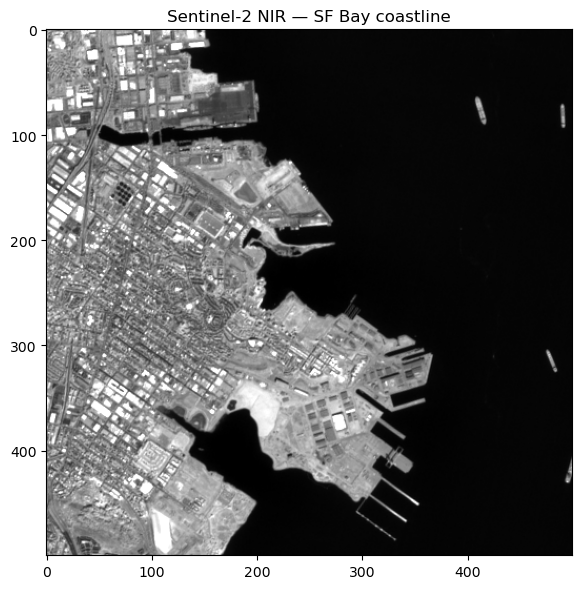

In [ ]:
import os, rasterio
from rasterio.windows import Window

os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'
os.environ['GDAL_DISABLE_READDIR_ON_OPEN'] = 'EMPTY_DIR'

COG_URL = (
    'https://sentinel-cogs.s3.us-west-2.amazonaws.com/'
    'sentinel-s2-l2a-cogs/10/S/EG/2023/9/'
    'S2B_10SEG_20230921_0_L2A/B08.tif'
)

try:
    with rasterio.open(COG_URL) as src:
        nir = src.read(1, window=Window(5300, 2100, 500, 500)).astype(np.float64)
    print(f'Downloaded NIR band: {nir.shape}, range {nir.min():.0f}–{nir.max():.0f}')
except Exception as exc:
    print(f'Remote read failed ({exc}), using synthetic fallback')
    rng_sat = np.random.default_rng(99)
    nir = np.zeros((500, 500), dtype=np.float64)
    # Water: low reflectance, smooth
    nir[:, 250:] = rng_sat.normal(80, 10, (500, 250)).clip(20, 200)
    # Land: high reflectance, rough
    nir[:, :250] = rng_sat.normal(1800, 400, (500, 250)).clip(300, 4000)

satellite = xr.DataArray(nir, dims=['y', 'x'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(nir, cmap='gray', vmin=0, vmax=np.percentile(nir, 98))
ax.set_title('Sentinel-2 NIR — SF Bay coastline')
plt.tight_layout()
plt.show()

### Step 2 — Compute GLCM texture features

We pick four metrics that tend to separate water (uniform, high energy, high homogeneity) from land (rough, high contrast):

| Metric | Water (smooth) | Land (rough) |
|---|---|---|
| contrast | low | high |
| homogeneity | high | low |
| energy | high | low |
| correlation | high (uniform) | lower (varied) |

An 11 x 11 window gives enough spatial context at 10 m resolution (110 m footprint).

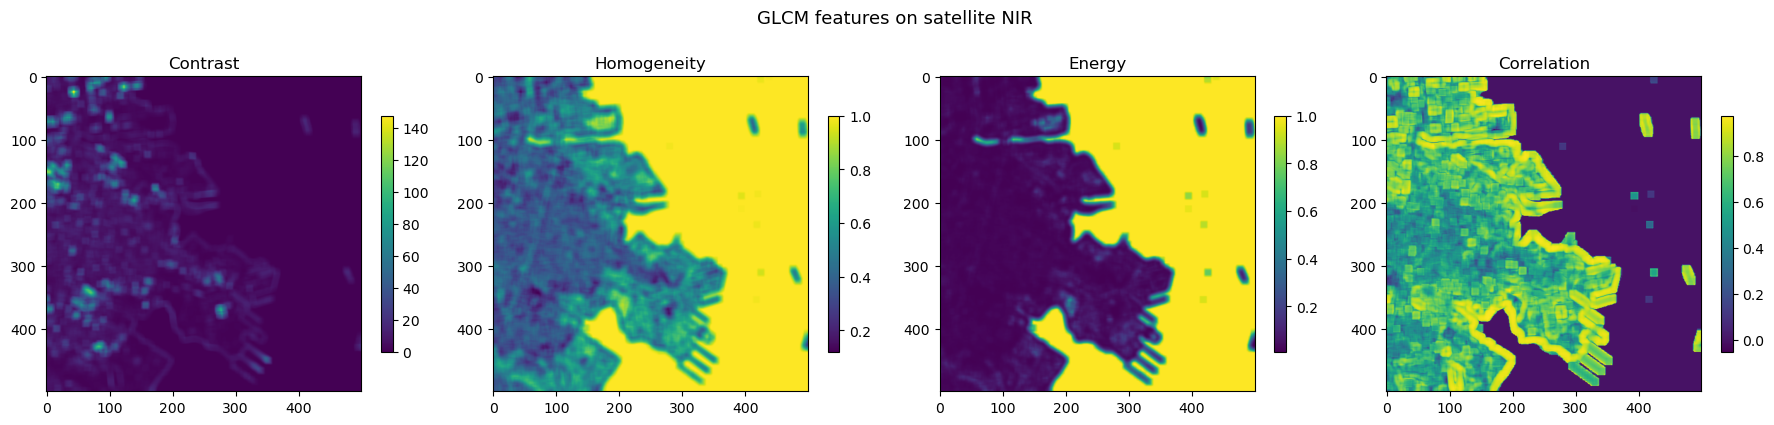

In [ ]:
sat_metrics = ['contrast', 'homogeneity', 'energy', 'correlation']
sat_textures = glcm_texture(satellite, metric=sat_metrics, window_size=11, levels=64)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, sat_metrics):
    vals = sat_textures.sel(metric=name).values
    im = ax.imshow(vals, cmap='viridis')
    ax.set_title(name.capitalize())
    plt.colorbar(im, ax=ax, shrink=0.7)
plt.suptitle('GLCM features on satellite NIR', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Step 3 — Classify water vs. land with KMeans

We stack the four texture layers into a feature vector per pixel, normalize them,
and let KMeans find two clusters. No training labels needed — the texture
difference between water and land is large enough that unsupervised clustering
picks it up cleanly.

After clustering, we check which cluster has lower mean NIR reflectance and
label that one "water."

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Stack texture features: (H, W, 4)
feature_stack = np.stack(
    [sat_textures.sel(metric=m).values for m in sat_metrics], axis=-1
)
h, w, n_feat = feature_stack.shape

# Mask out NaN edges left by the GLCM window
valid = ~np.any(np.isnan(feature_stack), axis=-1)
X = feature_stack[valid]

# Normalize and cluster
X_scaled = StandardScaler().fit_transform(X)
labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_scaled)

# Build the classification raster
class_map = np.full((h, w), np.nan)
class_map[valid] = labels

# Assign "water" to the cluster with lower NIR reflectance
cluster_nir = [np.nanmean(nir[class_map == c]) for c in range(2)]
water_id = int(np.argmin(cluster_nir))

water_mask = np.where(valid, class_map == water_id, np.nan)
print(f'Water cluster: {water_id} (mean NIR {cluster_nir[water_id]:.0f})')
print(f'Land  cluster: {1 - water_id} (mean NIR {cluster_nir[1 - water_id]:.0f})')

Water cluster: 1 (mean NIR 72)
Land  cluster: 0 (mean NIR 1877)


### Result

Left: the NIR image (bright = land, dark = water). Right: the GLCM-based classification. The shoreline comes through cleanly without any hand-drawn training polygons.

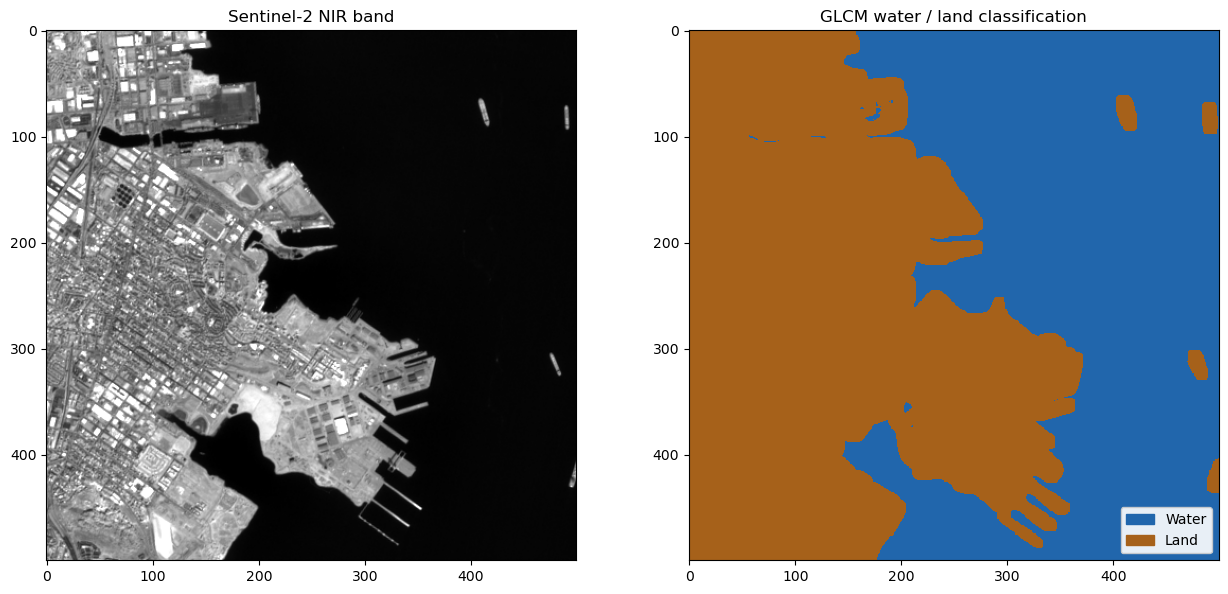

In [ ]:
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# NIR image
axes[0].imshow(nir, cmap='gray', vmin=0, vmax=np.percentile(nir, 98))
axes[0].set_title('Sentinel-2 NIR band')

# Classification
water_cmap = ListedColormap(['#a6611a', '#2166ac'])  # 0=land(brown), 1=water(blue)
im = axes[1].imshow(
    np.where(valid, class_map == water_id, np.nan),
    cmap=water_cmap, vmin=0, vmax=1, interpolation='nearest',
)
axes[1].set_title('GLCM water / land classification')

# Legend
from matplotlib.patches import Patch
axes[1].legend(
    handles=[Patch(color='#2166ac', label='Water'),
             Patch(color='#a6611a', label='Land')],
    loc='lower right', framealpha=0.9,
)

plt.tight_layout()
plt.show()

### Where to go from here

- **More clusters.** Bump `n_clusters` to 3 or 4 to split out mud flats, urban areas, or vegetation.
- **Supervised classification.** Replace KMeans with a Random Forest trained on labeled polygons for higher accuracy.
- **Larger areas.** Wrap the satellite DataArray in `dask.array.from_array` and `glcm_texture` will process it chunk-by-chunk, the same way we showed in the Dask section above.
- **Multi-band features.** Compute GLCM on several spectral bands and stack the results for a richer feature space.